In [64]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#### Get the flood dataset

In [65]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,1001,2000,ALABAMA,AUTAUGA,1,200000.0,3.50
1,1001,2001,ALABAMA,AUTAUGA,2,37000.0,4.25
2,1001,2003,ALABAMA,AUTAUGA,2,58000.0,6.00
3,1001,2004,ALABAMA,AUTAUGA,1,8000.0,3.50
4,1001,2005,ALABAMA,AUTAUGA,6,19000.0,76.00
...,...,...,...,...,...,...,...
35445,56045,2012,WYOMING,WESTON,1,5000.0,1.00
35446,56045,2013,WYOMING,WESTON,3,135000.0,8.33
35447,56045,2015,WYOMING,WESTON,4,30000.0,37.08
35448,56045,2018,WYOMING,WESTON,1,0.0,40.08


#### Get the HPI dataset

In [66]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()

,cbsa_code,cbsa_title,county_fips5,county/county_equivalent,state_name,place_name,place_id,yr,index_nsa,index_prev,hpi_change,hpi_yoy
13755,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2000,114.6775,113.7350,0.9425,0.828681
13756,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2001,119.9250,114.6775,5.2475,4.575876
13757,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2002,122.0075,119.9250,2.0825,1.736502
13758,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2003,125.8200,122.0075,3.8125,3.124808
13759,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2004,129.5400,125.8200,3.7200,2.956605
...,...,...,...,...,...,...,...,...,...,...,...,...
3124,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2016,273.0800,278.0150,-4.9350,-1.775084
3125,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2017,269.6775,273.0800,-3.4025,-1.245972
3126,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2018,273.1500,269.6775,3.4725,1.287649
3127,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2019,280.6300,273.1500,7.4800,2.738422


#### Checking for missing counties

In [67]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [68]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56025)

In [69]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2170, 41031,  9120,  9190,  2090,  9110,  9130, 15005,  9170,
        9180, 53059, 13173,  9140])

In [70]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1005,  1011,  1013, ..., 56041, 56043, 56045], shape=(2115,))

#### Merge flood and HPI datasets

In [71]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="inner",
)
hpi_flood  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20
...,...,...,...,...,...,...,...,...,...,...
12945,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50
12946,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00
12947,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00
12948,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83


In [72]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["FIPS", "YEAR"])
    .reset_index()
    .sort_values(by=["FIPS", "YEAR"])
)
temp[temp["count"] > 1]

,FIPS,YEAR,count


#### Get heat dataset

In [73]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [74]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [75]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [76]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [77]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["FIPS", "YEAR"],
    right_on=["FIPS", "year"],
    how="inner",
)
hpi_flood_heat  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,year,value,heat_index,HSI
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08,2002,90.8,0.059089,0.323792
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00,2003,92.8,0.178862,0.442478
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18,2004,89.6,-0.000561,0.413233
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02,2005,91.3,0.098956,0.344927
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20,2007,87.9,-0.029850,0.220479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12904,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50,2014,105.0,0.336505,0.863331
12905,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00,2015,105.8,0.383922,0.838107
12906,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00,2016,106.9,0.414770,0.872492
12907,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83,2018,106.4,0.402691,0.818690


In [78]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Get the drought and wildfire datasets

In [79]:
# GROUPED DROUGHT IN MERGED_DROUGHT_WILDFIRE TO REMOVE DUPLICATES

wildfire_drought = pd.read_csv(
    "../../02_processed_data/merged_wildfire_drought.csv"
).reset_index(drop=True)
wildfire_drought

,FIPS,Year,County,State_ncei,State_abbr,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,State_fire
0,1001,2003,Autauga County,Alabama,AL,2.39,43,274.80,AL
1,1001,2004,Autauga County,Alabama,AL,0.00,86,744.50,AL
2,1001,2005,Autauga County,Alabama,AL,0.90,63,234.20,AL
3,1001,2006,Autauga County,Alabama,AL,-1.34,62,534.70,AL
4,1001,2007,Autauga County,Alabama,AL,-3.33,93,477.30,AL
...,...,...,...,...,...,...,...,...,...
41622,56045,2016,Weston County,Wyoming,WY,-2.27,34,2775.14,WY
41623,56045,2017,Weston County,Wyoming,WY,-1.32,33,96.40,WY
41624,56045,2018,Weston County,Wyoming,WY,4.41,15,96.90,WY
41625,56045,2019,Weston County,Wyoming,WY,7.09,13,93.05,WY


In [80]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought.value_counts(subset=["FIPS", "Year"])
    .reset_index()
    .sort_values(by=["FIPS", "Year"])
)
temp[temp["count"] > 1]

,FIPS,Year,count


#### Merge Drought/Wildfire/HPI/Flood/Heat dataset

In [81]:
wildfire_drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    wildfire_drought,
    left_on=["FIPS", "YEAR"],
    right_on=["FIPS", "Year"],
    how="inner",
)
wildfire_drought_hpi_flood_heat.head()  # .sort_values(by=["FIPS", "YEAR"])
wildfire_drought_hpi_flood_heat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7977 entries, 0 to 7976
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   county_fips5           7977 non-null   int64  
 1   yr                     7977 non-null   int64  
 2   hpi_yoy                7977 non-null   float64
 3   FIPS                   7977 non-null   int64  
 4   YEAR                   7977 non-null   int64  
 5   STATE                  7977 non-null   object 
 6   CZ_NAME                7977 non-null   object 
 7   COUNT                  7977 non-null   int64  
 8   TOTAL_DAMAGE_PROPERTY  7977 non-null   float64
 9   TOTAL_DURATION_HOURS   7977 non-null   float64
 10  year                   7977 non-null   int64  
 11  value                  7977 non-null   float64
 12  heat_index             7977 non-null   float64
 13  HSI                    7977 non-null   float64
 14  Year                   7977 non-null   int64  
 15  Coun

In [82]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["FIPS", "Year"])
    .reset_index()
    .sort_values(by=["FIPS", "Year"])
)
temp[temp["count"] > 1]

,FIPS,Year,count


#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [83]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [84]:
wildfire_drought_hpi_flood_heat_huricane = wildfire_drought_hpi_flood_heat.merge(
    huricane_grouped, left_on=["FIPS", "YEAR"], right_on=["FIPS", "year"], how="inner"
)

# # sanity checks
# print(hpi_flood_heat.shape, storm2.shape, hpi_flood_heat_joined.shape)
# print(
#     "Left dups:",
#     hfh2.duplicated(["FIPS", "YEAR"]).sum(),
#     "| Right dups:",
#     storm2.duplicated(["FIPS", "YEAR"]).sum(),
# )
wildfire_drought_hpi_flood_heat_huricane

# wildfire_drought_hpi_flood_heat_huricane.to_csv(
#     "/Users/ramilmammadov/Desktop/Capstone Project/GitHub Repo/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/wildfire_drought_hpi_flood_heat_huricane.csv",
#     index=False
# )

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,...,State_ncei,State_abbr,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,State_fire,year_y,deaths_hurricane,injuries_hurricane,damage_hurricane
0,13095,2018,2.094798,13095,2018,GEORGIA,DOUGHERTY,3,0.0,6.28,...,Georgia,GA,0.54,12,71.41,GA,2018,0.0,0.0,411000000
1,13177,2005,5.926110,13177,2005,GEORGIA,LEE,12,0.0,3.28,...,Georgia,GA,1.82,38,86.14,GA,2005,0.0,0.0,100000
2,13177,2018,2.094798,13177,2018,GEORGIA,LEE,21,100000.0,15.98,...,Georgia,GA,0.73,6,7.32,GA,2018,0.0,0.0,116000000
3,13273,2005,5.926110,13273,2005,GEORGIA,TERRELL,2,300000.0,4.00,...,Georgia,GA,1.78,6,25.44,GA,2005,0.0,0.0,250000
4,13321,2005,5.926110,13321,2005,GEORGIA,WORTH,1,1750000.0,8.00,...,Georgia,GA,1.34,50,144.84,GA,2005,0.0,0.0,1750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,37019,2018,6.374252,37019,2018,NORTH CAROLINA,BRUNSWICK,10,550000.0,34.85,...,North Carolina,NC,2.37,41,181.98,NC,2018,0.0,0.0,200000
119,37129,2016,4.587577,37129,2016,NORTH CAROLINA,NEW HANOVER,13,2305000.0,42.27,...,North Carolina,NC,3.79,15,21.43,NC,2016,0.0,0.0,0
120,37129,2018,6.374252,37129,2018,NORTH CAROLINA,NEW HANOVER,9,2350000.0,34.02,...,North Carolina,NC,4.73,2,0.75,NC,2018,1.0,1.0,1000000000
121,37141,2016,4.587577,37141,2016,NORTH CAROLINA,PENDER,13,925000.0,36.67,...,North Carolina,NC,4.19,27,37.62,NC,2016,0.0,0.0,0


## EDA on merged dataset

In [85]:
for_training = wildfire_drought_hpi_flood_heat[
    [
        # "FIPS",
        "hpi_yoy",
        # "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
        # "value",  # heat
        "heat_index",
        # "HSI",
        "Annual_Mean_Index",  # drought
        "FIRE_FREQUENCY",
        "TOTAL_FIRE_SIZE",
    ]
]
for_training = for_training.rename(
    columns={
        "hpi_yoy": "HPI_YoY",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        # "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
    }
)

In [86]:
import numpy as np

for_training["LOG_FLOOD_DAMAGE"] = np.log1p(for_training["FLOOD_PROPERTY_DAMAGE"])
for_training["LOG_FIRE_SIZE"] = np.log1p(for_training["FIRE_SIZE"])
for_training["LOG_FIRE_FREQUENCY"] = np.log1p(for_training["FIRE_FREQUENCY"])
for_training["LOG_FLOOD_DURATION_HOURS"] = np.log1p(
    for_training["FLOOD_DURATION_HOURS"]
)
for_training["LOG_FLOOD_FREQUENCY"] = np.log1p(for_training["FLOOD_FREQUENCY"])

for_training = for_training.drop(
    columns=[
        "FLOOD_PROPERTY_DAMAGE",
        "FIRE_SIZE",
        "FIRE_FREQUENCY",
        "FLOOD_FREQUENCY",
        "FLOOD_DURATION_HOURS",
    ]
)

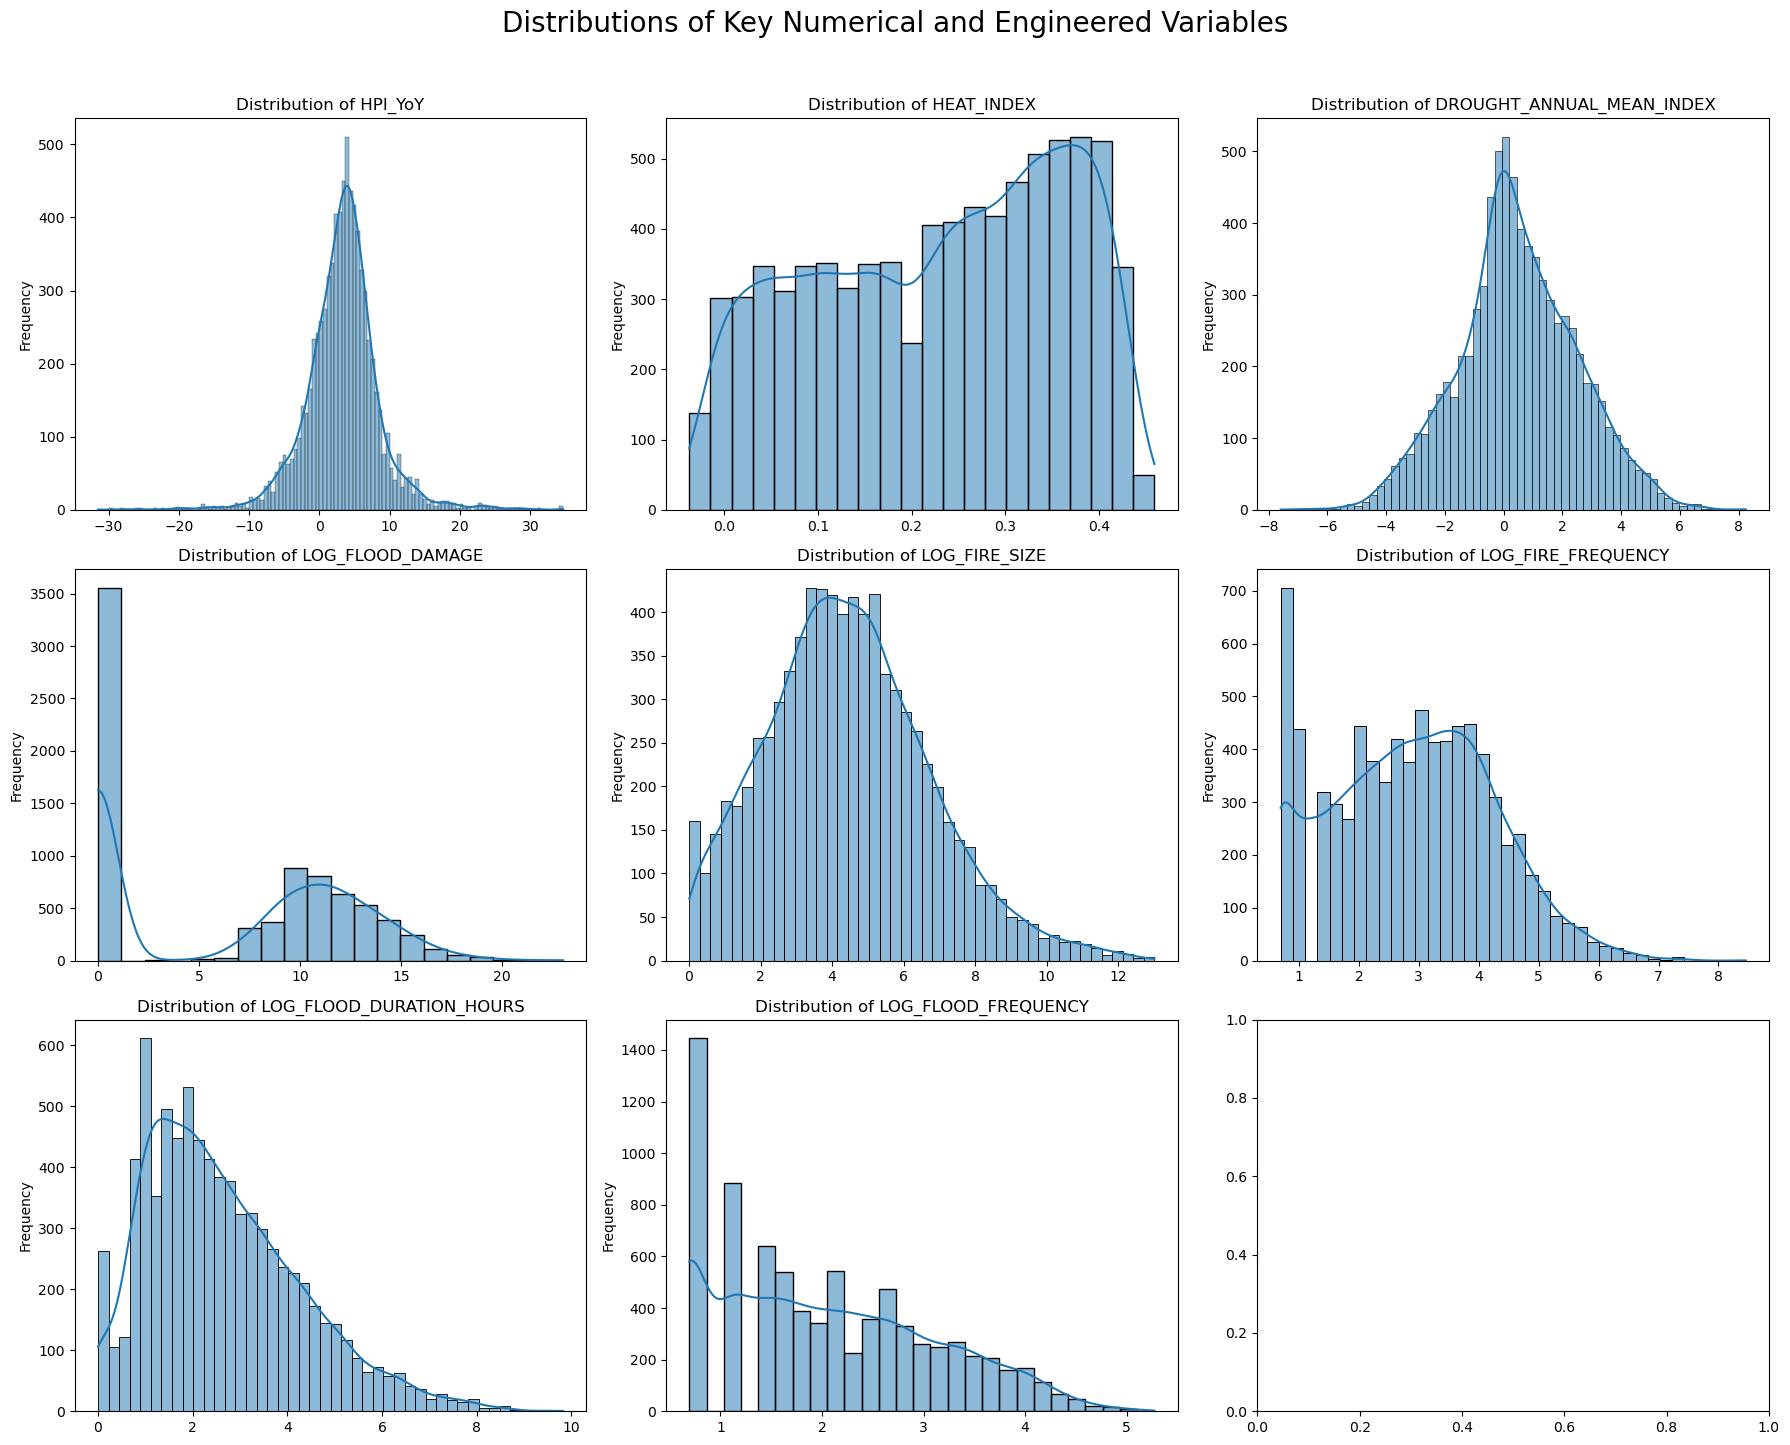

In [87]:
# Create a figure with a 3x3 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))

# The .flatten() function turns the 3x3 grid into a simple list to loop over
for col, ax in zip(for_training, axes.flatten()):
    sns.histplot(data=for_training, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel("")  # Remove individual x-labels for a cleaner look
    ax.set_ylabel("Frequency")

# Add a main title to the entire figure
fig.suptitle(
    "Distributions of Key Numerical and Engineered Variables", fontsize=20, y=0.99
)

# Automatically adjust subplot spacing to prevent labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

In [88]:
# max(for_training["FLOOD_PROPERTY_DAMAGE"]), for_training[
#     "FLOOD_PROPERTY_DAMAGE"
# ].median()
# for_training = for_training.drop(
#     for_training[for_training["FLOOD_PROPERTY_DAMAGE"] > 1000051100].index
# )

In [89]:
# Split data into features and target
y = for_training["HPI_YoY"]
X = for_training.drop(columns=["HPI_YoY"])  # ,"FIPS","YEAR"

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train_not_scaled, X_test_not_scaled, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
# # Fit scaler only on the training set
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train_not_scaled)

# # Apply the same transformation to the test set
# X_test = scaler.transform(X_test_not_scaled)

#### Checking for multicollinearity

In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])
]
print(vif)

                     feature        VIF
0                      const  15.332090
1                 HEAT_INDEX   1.254742
2  DROUGHT_ANNUAL_MEAN_INDEX   1.501274
3           LOG_FLOOD_DAMAGE   1.130576
4              LOG_FIRE_SIZE   1.787765
5         LOG_FIRE_FREQUENCY   1.755999
6   LOG_FLOOD_DURATION_HOURS   1.329369
7        LOG_FLOOD_FREQUENCY   1.148058


In [97]:
corr = X.corr().abs()
high_corr = corr[corr > 0.8]
print(high_corr)

                           HEAT_INDEX  DROUGHT_ANNUAL_MEAN_INDEX  \
HEAT_INDEX                        1.0                        NaN   
DROUGHT_ANNUAL_MEAN_INDEX         NaN                        1.0   
LOG_FLOOD_DAMAGE                  NaN                        NaN   
LOG_FIRE_SIZE                     NaN                        NaN   
LOG_FIRE_FREQUENCY                NaN                        NaN   
LOG_FLOOD_DURATION_HOURS          NaN                        NaN   
LOG_FLOOD_FREQUENCY               NaN                        NaN   

                           LOG_FLOOD_DAMAGE  LOG_FIRE_SIZE  \
HEAT_INDEX                              NaN            NaN   
DROUGHT_ANNUAL_MEAN_INDEX               NaN            NaN   
LOG_FLOOD_DAMAGE                        1.0            NaN   
LOG_FIRE_SIZE                           NaN            1.0   
LOG_FIRE_FREQUENCY                      NaN            NaN   
LOG_FLOOD_DURATION_HOURS                NaN            NaN   
LOG_FLOOD_FREQUENCY  

In [98]:
# Add a constant (intercept) for statsmodels
X_const = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X_const).fit()

# Print summary
print(model.summary())

# Optionally evaluate with train/test split
model_split = sm.OLS(y_train, X_train).fit()
y_pred = model_split.predict(X_test)

print("\nR² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

                            OLS Regression Results                            
Dep. Variable:                HPI_YoY   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     17.64
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           2.26e-23
Time:                        20:30:27   Log-Likelihood:                -24654.
No. Observations:                7977   AIC:                         4.932e+04
Df Residuals:                    7969   BIC:                         4.938e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

NameError: name 'X_train' is not defined

In [ ]:
w = 1 / (model.resid**2)
wls_model = sm.WLS(y, X_const, weights=w).fit()
print(wls_model.summary())

                            WLS Regression Results                            
Dep. Variable:                HPI_YoY   R-squared:                       0.998
Model:                            WLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 5.074e+05
Date:                Wed, 12 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:01:59   Log-Likelihood:                -17415.
No. Observations:                7977   AIC:                         3.485e+04
Df Residuals:                    7968   BIC:                         3.491e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# ---- STEP 1: Fit an initial OLS to get residuals ----
ols_model = sm.OLS(y_train, X_train_const).fit()

# Compute weights = 1 / residual² (classic heteroscedastic correction)
weights = 1 / (ols_model.resid**2)
weights.replace([np.inf, -np.inf], np.nan, inplace=True)
weights.fillna(weights.median(), inplace=True)

# ---- STEP 2: Fit Weighted Least Squares (WLS) using training weights ----
wls_model = sm.WLS(y_train, X_train_const, weights=weights).fit()

print(wls_model.summary())

# ---- STEP 3: Evaluate on test data ----
y_pred = wls_model.predict(X_test_const)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"\nTest R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

                            WLS Regression Results                            
Dep. Variable:                HPI_YoY   R-squared:                       0.999
Model:                            WLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.544e+06
Date:                Wed, 12 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:02:25   Log-Likelihood:                -13952.
No. Observations:                6381   AIC:                         2.792e+04
Df Residuals:                    6372   BIC:                         2.798e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3434      0.002   1445.358      0.0

/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ridge Regression
ridge = Pipeline(
    [("scaler", StandardScaler()), ("model", RidgeCV(alphas=[0.1, 1, 10], cv=5))]
)
ridge.fit(X_train, y_train)

print("R² (ridge):", ridge.score(X_test, y_test))

R² (ridge): 0.01611629271502335


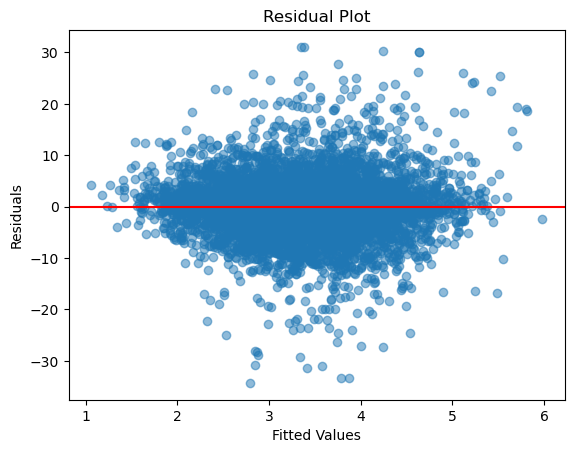

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(model.fittedvalues, model.resid, alpha=0.5)
plt.axhline(0, color="r")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

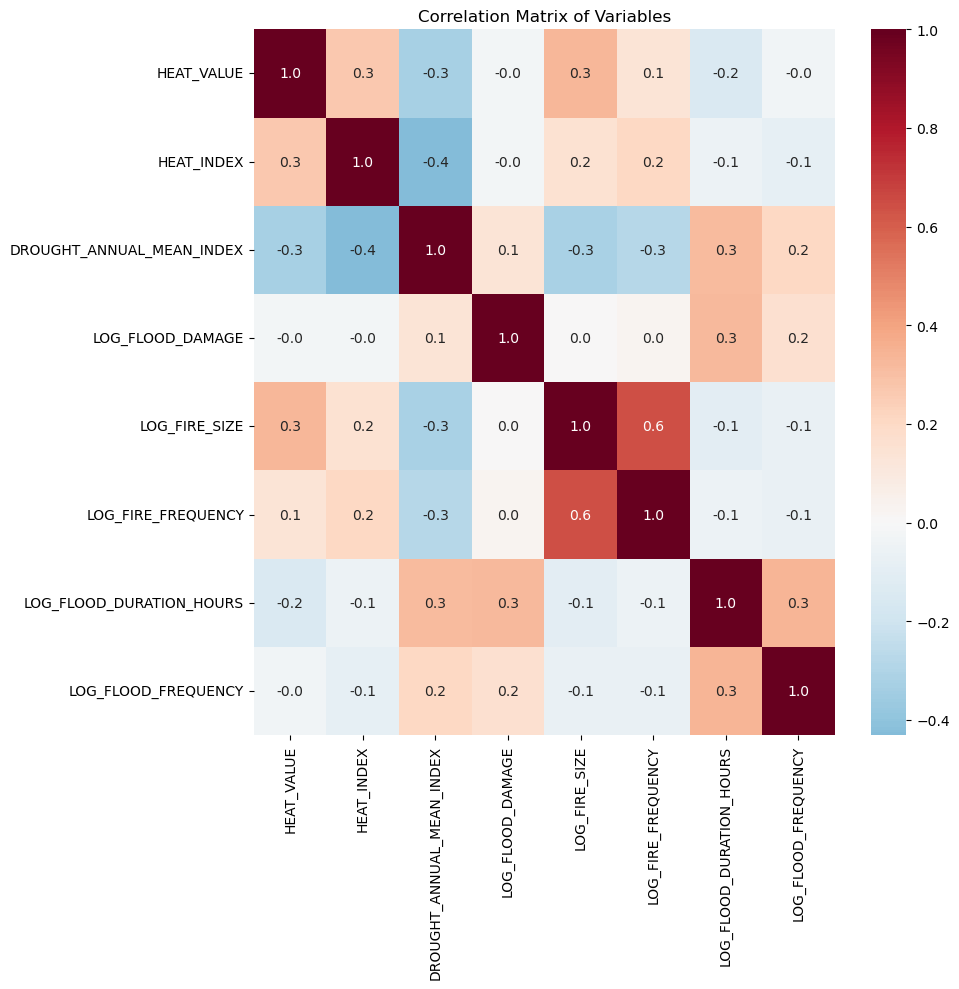

In [ ]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    corr,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

### Random Forest Regressor on the dataset

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("R² (RF):", rf.score(X_test, y_test))

R² (RF): 0.08127028102012634


In [ ]:
rf.feature_importances_

array([0.07871139, 0.07396188, 0.11474877, 0.15754883, 0.15485542,
       0.16217796, 0.12072573, 0.13727002])

## Autoregression Modeling 

In [99]:
for_AR = wildfire_drought_hpi_flood_heat[
    [
        # "FIPS",
        "hpi_yoy",
        "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
        "value",  # heat
        "heat_index",
        "HSI",
        "Annual_Mean_Index",  # drought
        "FIRE_FREQUENCY",
        "TOTAL_FIRE_SIZE",
    ]
]
for_AR = for_AR.rename(
    columns={
        "hpi_yoy": "HPI_YoY",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        "HSI": "HEAT_HSI",
    }
)

In [100]:
for_AR

,HPI_YoY,YEAR,FLOOD_FREQUENCY,FLOOD_PROPERTY_DAMAGE,FLOOD_DURATION_HOURS,HEAT_VALUE,HEAT_INDEX,HEAT_HSI,DROUGHT_ANNUAL_MEAN_INDEX,FIRE_FREQUENCY,FIRE_SIZE
0,2.620052,2003,2,0.0,2.00,92.8,0.178862,0.442478,0.96,1,100.00
1,4.455241,2004,4,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19,61.00
2,6.922266,2005,2,50000.0,4.02,91.3,0.098956,0.344927,1.93,16,10011.00
3,6.076846,2007,6,2000.0,13.20,87.9,-0.029850,0.220479,1.30,14,489.00
4,1.612448,2012,1,0.0,6.00,95.7,0.353297,0.507034,-1.76,54,89.56
...,...,...,...,...,...,...,...,...,...,...,...
7972,3.042566,2014,3,0.0,8.50,105.0,0.336505,0.863331,-1.05,33,1160.25
7973,4.932343,2015,4,100000.0,3.00,105.8,0.383922,0.838107,-1.70,8,101.40
7974,3.794342,2016,3,0.0,3.00,106.9,0.414770,0.872492,-2.68,11,1326.60
7975,3.642268,2018,7,65000.0,17.83,106.4,0.402691,0.818690,-2.95,191,594.87


In [101]:
# can you do with Heteroscedasticity Correction?
import pandas as pd
import statsmodels.api as sm

# Keep 5 years of data
# subset = for_AR[for_AR['YEAR'].between(2016, 2020)]

# Define time series
y = for_AR["HPI_YoY"].astype(float)

# Fit AR(1)
model = sm.tsa.ARIMA(y, order=(1, 0, 0))  # AR(1)
results = model.fit()

print(results.summary())

# Forecast 5 steps ahead (next 5 years)
forecast = results.forecast(steps=10)
print("Forecast for next 5 years:")
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                HPI_YoY   No. Observations:                 7977
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -23541.968
Date:                Tue, 18 Nov 2025   AIC                          47089.936
Time:                        20:35:07   BIC                          47110.889
Sample:                             0   HQIC                         47097.109
                               - 7977                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3616      0.110     30.540      0.000       3.146       3.577
ar.L1          0.5047      0.005     94.542      0.000       0.494       0.515
sigma2        21.4271      0.156    137.181      0.0

In [102]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# === Step 1: Prepare your time series ===
# Assuming `flood` has ['YEAR', 'HPI_YoY'] columns
flood = for_AR.sort_values("YEAR")
y = flood["HPI_YoY"].dropna().astype(float)

# === Step 2: Fit AR(1) model ===
ar1_model = sm.tsa.ARIMA(y, order=(1, 0, 0))
ar1_results = ar1_model.fit()
print("\n=== AR(1) Summary ===")
print(ar1_results.summary())

# === Step 3: Test for heteroscedasticity (ARCH test) ===
# Null hypothesis: no ARCH effects (homoscedastic)
arch_test = het_arch(ar1_results.resid)
print("\nARCH test p-value:", arch_test[1])

if arch_test[1] < 0.05:
    print(
        "⚠️ Significant heteroscedasticity detected — switching to AR(1)-GARCH(1,1)..."
    )

    # === Step 4: Fit AR(1)-GARCH(1,1) ===
    garch_model = arch_model(y, mean="AR", lags=1, vol="GARCH", p=1, q=1)
    garch_results = garch_model.fit(disp="off")

    print("\n=== AR(1)-GARCH(1,1) Summary ===")
    print(garch_results.summary())

    # === Step 5: Forecast 5 steps ahead ===
    forecast = garch_results.forecast(horizon=5)
    print("\nForecasted mean values (next 5 years):")
    print(forecast.mean.tail(1))
else:
    print("✅ No significant heteroscedasticity — keeping AR(1) model.")

    # === Step 5: Forecast 5 steps ahead ===
    forecast = ar1_results.forecast(steps=5)
    print("\nForecasted mean values (next 5 years):")
    print(forecast)


=== AR(1) Summary ===
                               SARIMAX Results                                
Dep. Variable:                HPI_YoY   No. Observations:                 7977
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -23581.234
Date:                Tue, 18 Nov 2025   AIC                          47168.467
Time:                        20:35:11   BIC                          47189.420
Sample:                             0   HQIC                         47175.640
                               - 7977                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3616      0.104     32.328      0.000       3.158       3.565
ar.L1          0.4974      0.007     69.598      0.000       0.483       0.511
sigma2        21.6386      0.

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# -------------------------
# 1. Load your data
# -------------------------
# Make sure your dataframe has columns: ds (date), y (value)
# Example dataset:
# df = pd.read_csv("your_timeseries.csv")

# Example synthetic data:
# date_range = pd.date_range(start="2020-01-01", periods=100)
# df = pd.DataFrame({
#     "ds": date_range,
#     "y": 50 + 0.5 * range(100)  # increasing trend
# })

for_prophet = for_AR[["YEAR", "HPI_YoY"]].copy()
for_prophet = for_prophet.rename(columns={"YEAR": "ds", "HPI_YoY": "y"})
# for_prophet = for_prophet["ds"].astype('datetime64[ns]')

# -------------------------
# 2. Fit the Prophet model
# -------------------------
model = Prophet()
model.fit(for_prophet)

# -------------------------
# 3. Make future predictions
# -------------------------
future = model.make_future_dataframe(periods=30)  # forecast 30 extra days
forecast = model.predict(future)

# -------------------------
# 4. Merge actuals with predictions
# -------------------------
print()
comparison = forecast[["ds", "yhat"]].merge(
    for_prophet[["ds", "y"]], on="ds", how="left"
)

# -------------------------
# 5. Plot Actual vs Predicted
# -------------------------
plt.figure(figsize=(12, 5))

plt.plot(comparison["ds"], comparison["y"], label="Actual", linewidth=2)
plt.plot(comparison["ds"], comparison["yhat"], label="Predicted (yhat)", linestyle="--")

plt.title("Prophet Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

20:40:20 - cmdstanpy - INFO - Chain [1] start processing
20:40:21 - cmdstanpy - INFO - Chain [1] done processing


ValueError: You are trying to merge on datetime64[ns] and int64 columns for key 'ds'. If you wish to proceed you should use pd.concat

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ------------------------------------------------
# 1. Load your dataset
# ------------------------------------------------
# df = pd.read_csv("your_data.csv")

# Variables you want to use:
exog_vars = [
    "FLOOD_FREQUENCY",
    "FLOOD_PROPERTY_DAMAGE",
    "FLOOD_DURATION_HOURS",
    "HEAT_VALUE",
    "HEAT_INDEX",
    "HSI",
    "DROUGHT_ANNUAL_MEAN_INDEX",
    "FIRE_FREQUENCY",
    "FIRE_SIZE",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
]

target = "HPI_YoY"

# ------------------------------------------------
# 2. Extract X and y
# ------------------------------------------------
X = df[exog_vars].values
y = df[target].values

# ------------------------------------------------
# 3. Train/Test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------
# 4. Normalize the features
# ------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------
# 5. Build a neural network
# ------------------------------------------------
model = Sequential(
    [
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),  # Regression output
    ]
)

model.compile(optimizer="adam", loss="mse")

# ------------------------------------------------
# 6. Train the model
# ------------------------------------------------
history = model.fit(
    X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=16, verbose=1
)

# ------------------------------------------------
# 7. Predict
# ------------------------------------------------
y_pred = model.predict(X_test_scaled).flatten()

# ------------------------------------------------
# 8. Accuracy metrics
# ------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# ------------------------------------------------
# 9. Plot Actual vs Predicted
# ------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title("Neural Network Prediction: Actual vs Predicted HPI_YoY")
plt.xlabel("Test Sample Index")
plt.ylabel("HPI_YoY")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()